In [1]:
import numpy as np
import torch

## Satellite Example

In [8]:
from test_functions import Satellite
from gp import train_multitask_gp
from acquisition import multitask_acquisition, optimize_acquisition
from active_learning import active_learning_loop
from botorch.utils.transforms import normalize, unnormalize, standardize 


dtype = torch.float64
device= "cpu"
filename = "hist_new.pt"
bounds  = torch.tensor([[0., 0., 0., 0., 0.], 
                        [2., 2., 2., 2., 2.]], dtype=dtype, device=device) # always a 2 x d tensor
x_input = unnormalize(torch.rand(10,5), bounds=bounds)

sat_prob = Satellite()
gpmodel = train_multitask_gp(sat_prob, num_train=10, seed=1111) 
active_learning_loop(gpmodel,acq_method = 'entropy', maxiters = 20, 
                     disp = True, save_hist = (x_input, filename, 'openmdao'), 
                     log_hyperparams = False)

## Review comment
# It looks like OpenMDAO is called internally to compute the true fixed point. Please make this
# optional and add a flag as a kwarg to turn this on if necessary (default should be off)

Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
Iter 6
Iter 7
Iter 8
Iter 9
Iter 10
Iter 11
Iter 12
Iter 13
Iter 14
Iter 15
Iter 16
Iter 17
Iter 18
Iter 19
Iter 20
done


Text(0, 0.5, 'distance from openMDAO result')

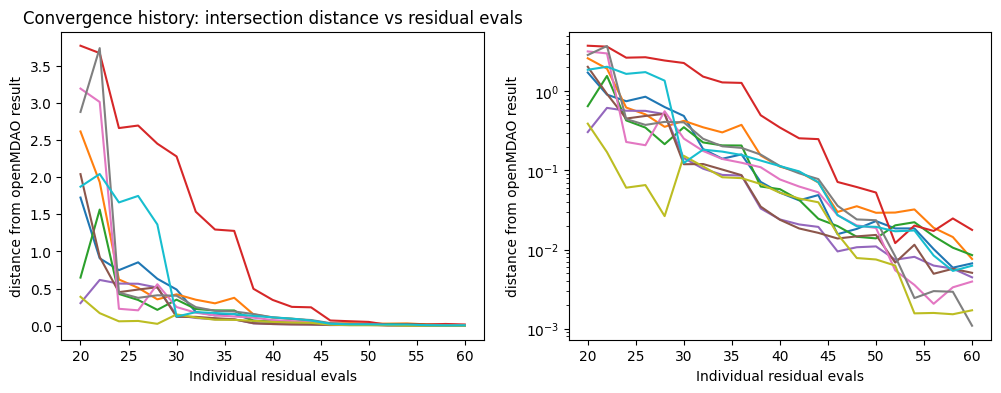

In [9]:
import torch
import matplotlib.pyplot as plt

history = torch.load(filename)
num_evals = history["num_evals"]
dist_history = history["dist_history"] 

fig = plt.figure(figsize=(12,4))

host = fig.add_subplot(121)
plt.plot(num_evals, dist_history)
host.set_title('Convergence history: intersection distance vs residual evals')
host.set_xlabel('Individual residual evals')
host.set_ylabel('distance from openMDAO result')

host = fig.add_subplot(122)
plt.semilogy(num_evals, dist_history)
host.set_xlabel('Individual residual evals')
host.set_ylabel('distance from openMDAO result')

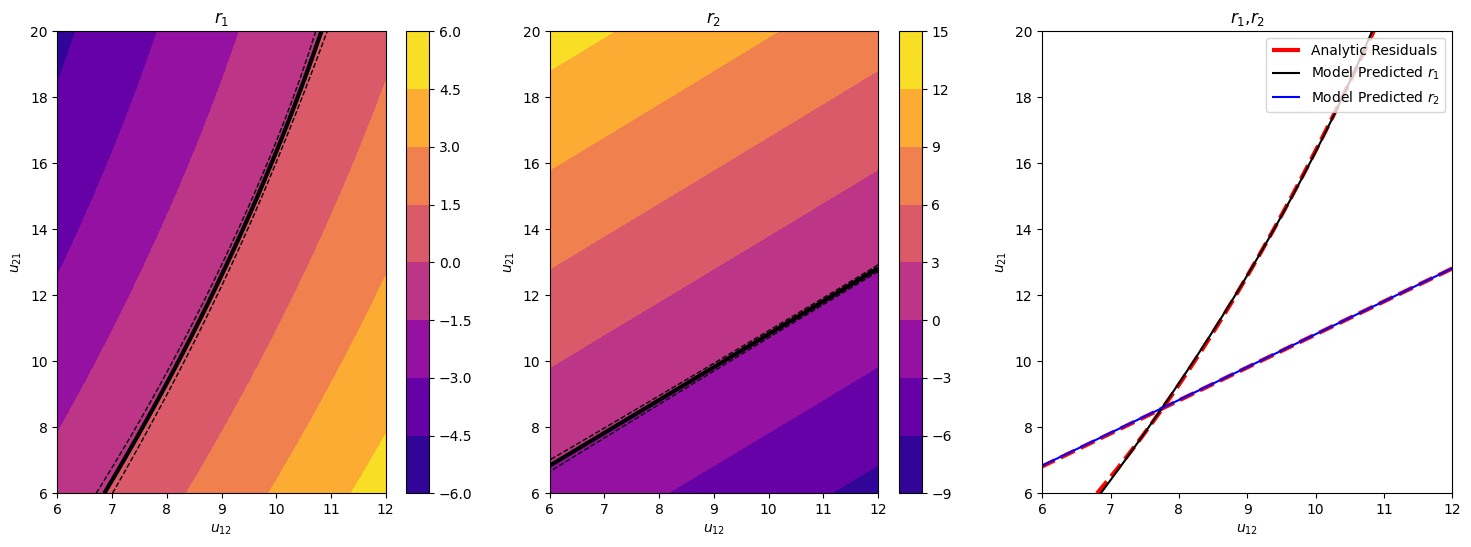

In [11]:
## Review comment
# Please avoid hardcoding!


import matplotlib.pyplot as plt
import torch
from botorch.utils.transforms import normalize
from utils import unstandardize

# This assumes that there are two coupling variables that we care about.

# Unpack result
mt_model = gpmodel.model
y = gpmodel.train_y
bounds = sat_prob.bounds
coupling_bounds = torch.transpose(bounds[:,-2:],0,1)

# Select inputs at which to make prediction ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# input_vec = torch.tensor(x_input[1,...]) # use input from above
input_vec = torch.rand(5)*2 # random input
npts = 40

# Generate test points 
xvec, yvec = torch.meshgrid(torch.linspace(*coupling_bounds[0,:],npts), # first coupling variable
                            torch.linspace(*coupling_bounds[1,:],npts), # second coupling variable
                            indexing='ij')

# Analytic
sat_prob.set_vars(torch.column_stack([input_vec.repeat(npts**2,1),xvec.reshape(-1,1),yvec.reshape(-1,1)]))

r1vec = sat_prob.res[:,0]
r2vec = sat_prob.res[:,1]

# Predictions
test_x = torch.column_stack([input_vec.repeat(npts**2,1),
                             xvec.reshape(-1,1),
                             yvec.reshape(-1,1)])
test_x = normalize(test_x,bounds)
test_x1 = torch.column_stack([test_x, torch.ones(npts**2,1)*0]) # task id1
test_x2 = torch.column_stack([test_x, torch.ones(npts**2,1)*1]) # task id2
# test_x1.requires_grad = True

# Write a function unstandardize() to do this.
# prediction1 = y.mean().item()+(mt_model.likelihood(mt_model(test_x1)))*y.std().item()
# prediction2 = y.mean().item()+(mt_model.likelihood(mt_model(test_x2)))*y.std().item()
prediction1 = unstandardize(mt_model.likelihood(mt_model(test_x1)), y)
prediction2 = unstandardize(mt_model.likelihood(mt_model(test_x2)), y)

fig = plt.figure(figsize=(18,6))

# r1 +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax1 = fig.add_subplot(131)
cf1 = ax1.contourf(xvec, yvec, prediction1.mean.detach().numpy().reshape(npts,npts),
                  cmap = 'plasma')
ax1.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(npts, npts) + 2.* prediction1.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(npts, npts) - 2.* prediction1.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax1.scatter(train_x1[...,-2],train_x1[...,-1],c='w',s=15)
fig.colorbar(cf1)
ax1.set_title(r'$r_1$')
ax1.set_xlabel(r'$u_{12}$')
ax1.set_ylabel(r'$u_{21}$')



# r2 residual +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax2 = fig.add_subplot(132)
cf2 = ax2.contourf(xvec, yvec, prediction2.mean.detach().numpy().reshape(npts,npts),
                  cmap = 'plasma')
ax2.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(npts, npts) + 2.* prediction2.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(npts, npts) - 2.* prediction2.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax2.scatter(train_x2[...,-2],train_x2[...,-1],c='w',s=15)
fig.colorbar(cf2)
ax2.set_title(r'$r_2$')
ax2.set_xlabel(r'$u_{12}$')
ax2.set_ylabel(r'$u_{21}$')



# both ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax3 = fig.add_subplot(133)
# cf3 = ax3.contourf(xvec,yvec,prediction3.mean.detach().numpy().reshape(40,40),
#              cmap = 'plasma')
# fig.colorbar(cf3)
s1 = ax3.contour(xvec,yvec,r1vec.reshape(npts,npts),
            levels=[0.],
            linestyles='--', linewidths=3, colors='r')
s1_artist,_ = s1.legend_elements()
ax3.contour(xvec,yvec,r2vec.reshape(npts,npts),
            levels=[0.],
            linestyles='--', linewidths=3, colors='r')
s2 = ax3.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='k')
s2_artist,_ = s2.legend_elements()
s3 = ax3.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='b')
s3_artist,_ = s3.legend_elements()
ax3.set_title(r'$r_1$,$r_2$')
ax3.set_xlabel(r'$u_{12}$')
ax3.set_ylabel(r'$u_{21}$')
#ax3.legend([s1_artist, s3_artist], ['Analytic Residuals','Model Residuals'])
ax3.legend([s1_artist[0], s2_artist[0], s3_artist[0]],['Analytic Residuals','Model Predicted $r_1$','Model Predicted $r_2$'])

## Aerostructural Example

In [6]:
from test_functions import Aerostructures
from gp import train_multitask_gp
from acquisition import multitask_acquisition, optimize_acquisition
from active_learning import active_learning_loop
from botorch.utils.transforms import normalize, unnormalize, standardize 

dtype = torch.float64
device= "cpu"
filename = "hist_aero.pt"
bounds  = torch.tensor([[0.  ],
                        [200.]], dtype=dtype, device=device) # always a 2 x d tensor
x_input = unnormalize(torch.rand(5,1), bounds=bounds)
# x_input = [100]

prob = Aerostructures()
gpmodel = train_multitask_gp(prob, num_train=120, seed=1111) 
active_learning_loop(gpmodel,
                     acq_method = 'entropy', maxiters = 30, 
                     disp = True, 
                     save_hist = (x_input, filename, 'openmdao'),
                     log_hyperparams = False)


Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
Iter 6
Iter 7
Iter 8
Iter 9
Iter 10
Iter 11
Iter 12
Iter 13
Iter 14
Iter 15
Iter 16
Iter 17
Iter 18
Iter 19
Iter 20
Iter 21
Iter 22
Iter 23
Iter 24
Iter 25
Iter 26
Iter 27
Iter 28
Iter 29
Iter 30
done


Text(0, 0.5, 'distance from openMDAO result')

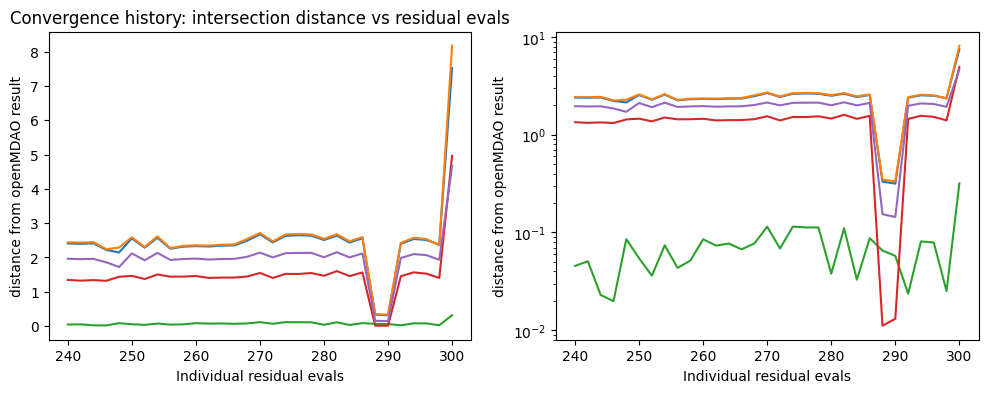

In [7]:
import torch
import matplotlib.pyplot as plt

history = torch.load("hist_aero.pt")
num_evals = history["num_evals"]
dist_history = history["dist_history"] 

fig = plt.figure(figsize=(12,4))

host = fig.add_subplot(121)
plt.plot(num_evals, dist_history)
host.set_title('Convergence history: intersection distance vs residual evals')
host.set_xlabel('Individual residual evals')
host.set_ylabel('distance from openMDAO result')

host = fig.add_subplot(122)
plt.semilogy(num_evals, dist_history)
host.set_xlabel('Individual residual evals')
host.set_ylabel('distance from openMDAO result')

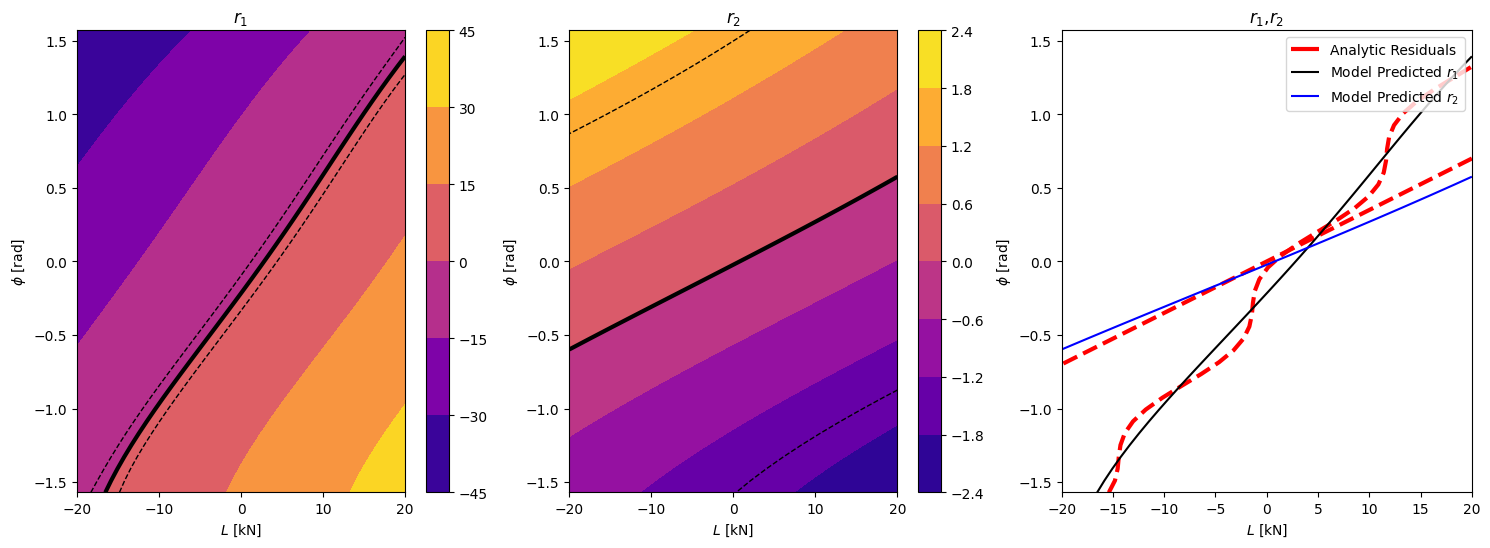

In [8]:
import matplotlib.pyplot as plt
import torch
from botorch.utils.transforms import normalize
from utils import unstandardize

# This assumes that there are two coupling variables that we care about.

# Unpack result
mt_model = gpmodel.model
y = gpmodel.train_y
bounds = prob.bounds
coupling_bounds = torch.transpose(bounds[:,-2:],0,1)

# Select inputs at which to make prediction ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
input_vec = torch.tensor([200])
# input_vec = torch.rand(5)*2
npts = 40

# Generate test points 
xvec, yvec = torch.meshgrid(torch.linspace(*coupling_bounds[0,:],npts), # first coupling variable
                            torch.linspace(*coupling_bounds[1,:],npts), # second coupling variable
                            indexing='ij')

# Analytic
prob.set_vars(torch.column_stack([input_vec.repeat(npts**2,1),xvec.reshape(-1,1),yvec.reshape(-1,1)]))

r1vec = prob.res[:,0]
r2vec = prob.res[:,1]

# Predictions
test_x = torch.column_stack([input_vec.repeat(npts**2,1),
                             xvec.reshape(-1,1),
                             yvec.reshape(-1,1)])
test_x = normalize(test_x,bounds)
test_x1 = torch.column_stack([test_x, torch.ones(npts**2,1)*0]) # task id1
test_x2 = torch.column_stack([test_x, torch.ones(npts**2,1)*1]) # task id2
# test_x1.requires_grad = True

# Write a function unstandardize() to do this.
# prediction1 = y.mean().item()+(mt_model.likelihood(mt_model(test_x1)))*y.std().item()
# prediction2 = y.mean().item()+(mt_model.likelihood(mt_model(test_x2)))*y.std().item()
prediction1 = unstandardize(mt_model.likelihood(mt_model(test_x1)), y)
prediction2 = unstandardize(mt_model.likelihood(mt_model(test_x2)), y)

fig = plt.figure(figsize=(18,6))

# r1 +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax1 = fig.add_subplot(131)
cf1 = ax1.contourf(xvec, yvec, prediction1.mean.detach().numpy().reshape(npts,npts),
                  cmap = 'plasma')
ax1.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(npts, npts) + 2.* prediction1.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(npts, npts) - 2.* prediction1.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax1.scatter(train_x1[...,-2],train_x1[...,-1],c='w',s=15)
fig.colorbar(cf1)
ax1.set_title(r'$r_1$')
ax1.set_xlabel(r'$L$ [kN]')
ax1.set_ylabel(r'$\phi$ [rad]')



# r2 residual +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax2 = fig.add_subplot(132)
cf2 = ax2.contourf(xvec, yvec, prediction2.mean.detach().numpy().reshape(npts,npts),
                  cmap = 'plasma')
ax2.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(npts, npts) + 2.* prediction2.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(npts, npts) - 2.* prediction2.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax2.scatter(train_x2[...,-2],train_x2[...,-1],c='w',s=15)
fig.colorbar(cf2)
ax2.set_title(r'$r_2$')
ax2.set_xlabel(r'$L$ [kN]')
ax2.set_ylabel(r'$\phi$ [rad]')



# both ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax3 = fig.add_subplot(133)
# cf3 = ax3.contourf(xvec,yvec,prediction3.mean.detach().numpy().reshape(40,40),
#              cmap = 'plasma')
# fig.colorbar(cf3)
s1 = ax3.contour(xvec,yvec,r1vec.reshape(npts,npts),
            levels=[0.],
            linestyles='--', linewidths=3, colors='r')
s1_artist,_ = s1.legend_elements()
ax3.contour(xvec,yvec,r2vec.reshape(npts,npts),
            levels=[0.],
            linestyles='--', linewidths=3, colors='r')
s2 = ax3.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='k')
s2_artist,_ = s2.legend_elements()
s3 = ax3.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='b')
s3_artist,_ = s3.legend_elements()
ax3.set_title(r'$r_1$,$r_2$')
ax3.set_xlabel(r'$L$ [kN]')
ax3.set_ylabel(r'$\phi$ [rad]')
#ax3.legend([s1_artist, s3_artist], ['Analytic Residuals','Model Residuals'])
ax3.legend([s1_artist[0], s2_artist[0], s3_artist[0]],['Analytic Residuals','Model Predicted $r_1$','Model Predicted $r_2$'])

## Multiple runs

In [ ]:
from test_functions import Satellite
from gp import train_multitask_gp
from acquisition import multitask_acquisition, optimize_acquisition, entropy
from active_learning import active_learning_loop

x_input = torch.rand(10,5)*2
# 
for i in range(0,20):
    print("hist"+str(i))
    filename = "hist" + str(i) + ".pt"
    sat_prob = Satellite()
    result = train_multitask_gp(sat_prob, num_train=10, seed=1111)
    active_learning_loop(result,
                         acq_method = 'entropy', 
                         maxiters = 30, disp = True, 
                         save_hist = (x_input, filename))



In [ ]:
import torch
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12,3))
host = fig.add_subplot(111)

for i in range(0,20):
    history = torch.load("hist" + str(i) + ".pt")
    num_evals = history["num_evals"]
    dist_history = history["dist_history"]

    plt.plot(num_evals, dist_history)

# plt.axvline(x=40, color='red', linestyle='--', label="NLBGS Converged"

host.set_title('Convergence history: intersection distance vs residual evals')
host.set_xlabel('Individual residual evals')
host.set_ylabel('Distance from OpenMDAO result')

## Note: intersection distance converging to values larger than about 1E-2 indiciates that the intersection point occurs outside the bounds of the problem. This needs to be addressed. For example:

In [ ]:
import matplotlib.pyplot as plt
import torch
from botorch.utils.transforms import normalize
from utils import unstandardize

# This assumes that there are two coupling variables that we care about.

# Unpack result
mt_model = result.model
y = result.train_y
bounds = sat_prob.bounds
coupling_bounds = torch.transpose(bounds[:,-2:],0,1)

# Select inputs at which to make prediction ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
input_vec = torch.tensor([0.4074, 0.5940, 0.8677, 0.3936, 0.0059])
npts = 40

# Generate test points 
xvec, yvec = torch.meshgrid(torch.linspace(*coupling_bounds[0,:],npts), # first coupling variable
                            torch.linspace(*coupling_bounds[1,:],npts), # second coupling variable
                            indexing='ij')

# Analytic
sat_prob.set_vars(torch.column_stack([input_vec.repeat(npts**2,1),xvec.reshape(-1,1),yvec.reshape(-1,1)]))

r1vec = sat_prob.res[:,0]
r2vec = sat_prob.res[:,1]

# Predictions
test_x = torch.column_stack([input_vec.repeat(npts**2,1),
                             xvec.reshape(-1,1),
                             yvec.reshape(-1,1)])
test_x = normalize(test_x,bounds)
test_x1 = torch.column_stack([test_x, torch.ones(npts**2,1)*0]) # task id1
test_x2 = torch.column_stack([test_x, torch.ones(npts**2,1)*1]) # task id2
# test_x1.requires_grad = True

# Write a function unstandardize() to do this.
# prediction1 = y.mean().item()+(mt_model.likelihood(mt_model(test_x1)))*y.std().item()
# prediction2 = y.mean().item()+(mt_model.likelihood(mt_model(test_x2)))*y.std().item()
prediction1 = unstandardize(mt_model.likelihood(mt_model(test_x1)), y)
prediction2 = unstandardize(mt_model.likelihood(mt_model(test_x2)), y)

fig = plt.figure(figsize=(18,6))

# r1 +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax1 = fig.add_subplot(131)
cf1 = ax1.contourf(xvec, yvec, prediction1.mean.detach().numpy().reshape(npts,npts),
                  cmap = 'plasma')
ax1.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(npts, npts) + 2.* prediction1.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(npts, npts) - 2.* prediction1.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax1.scatter(train_x1[...,-2],train_x1[...,-1],c='w',s=15)
fig.colorbar(cf1)
ax1.set_title(r'$r_1$')
ax1.set_xlabel(r'$u_{12}$')
ax1.set_ylabel(r'$u_{21}$')



# r2 residual +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax2 = fig.add_subplot(132)
cf2 = ax2.contourf(xvec, yvec, prediction2.mean.detach().numpy().reshape(npts,npts),
                  cmap = 'plasma')
ax2.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(npts, npts) + 2.* prediction2.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(npts, npts) - 2.* prediction2.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax2.scatter(train_x2[...,-2],train_x2[...,-1],c='w',s=15)
fig.colorbar(cf2)
ax2.set_title(r'$r_2$')
ax2.set_xlabel(r'$u_{12}$')
ax2.set_ylabel(r'$u_{21}$')



# both ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax3 = fig.add_subplot(133)
# cf3 = ax3.contourf(xvec,yvec,prediction3.mean.detach().numpy().reshape(40,40),
#              cmap = 'plasma')
# fig.colorbar(cf3)
s1 = ax3.contour(xvec,yvec,r1vec.reshape(npts,npts),
            levels=[0.],
            linestyles='--', linewidths=3, colors='r')
s1_artist,_ = s1.legend_elements()
ax3.contour(xvec,yvec,r2vec.reshape(npts,npts),
            levels=[0.],
            linestyles='--', linewidths=3, colors='r')
s2 = ax3.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='k')
s2_artist,_ = s2.legend_elements()
s3 = ax3.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='b')
s3_artist,_ = s3.legend_elements()
ax3.set_title(r'$r_1$,$r_2$')
ax3.set_xlabel(r'$u_{12}$')
ax3.set_ylabel(r'$u_{21}$')
#ax3.legend([s1_artist, s3_artist], ['Analytic Residuals','Model Residuals'])
ax3.legend([s1_artist[0], s2_artist[0], s3_artist[0]],['Analytic Residuals','Model Predicted $r_1$','Model Predicted $r_2$'])